In [36]:
import duckdb
import random
from functions.analyte import ANALYTES
from networks.cnn_deep import CNNModel
from networks.auto_encoder import AutoencoderModel
from functions.evaluation import evaluate
from functions.full_model import predict


con = duckdb.connect('../capillary.db')

df = con.execute(""" 
                 SELECT row_id, age, gender, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set
                 FROM protein_data 
                 WHERE set = 'test'
                 AND observation_nr = 1
                 """).df()
df = df[df['label'].isin([0,1,2,4])]
df = predict(df)
con.close()

#slår ihop oligoklonalt och lätt avvikande
df.loc[df['label']==4,'label'] = 2
df.loc[df['final_prediction']==4,'final_prediction'] = 2


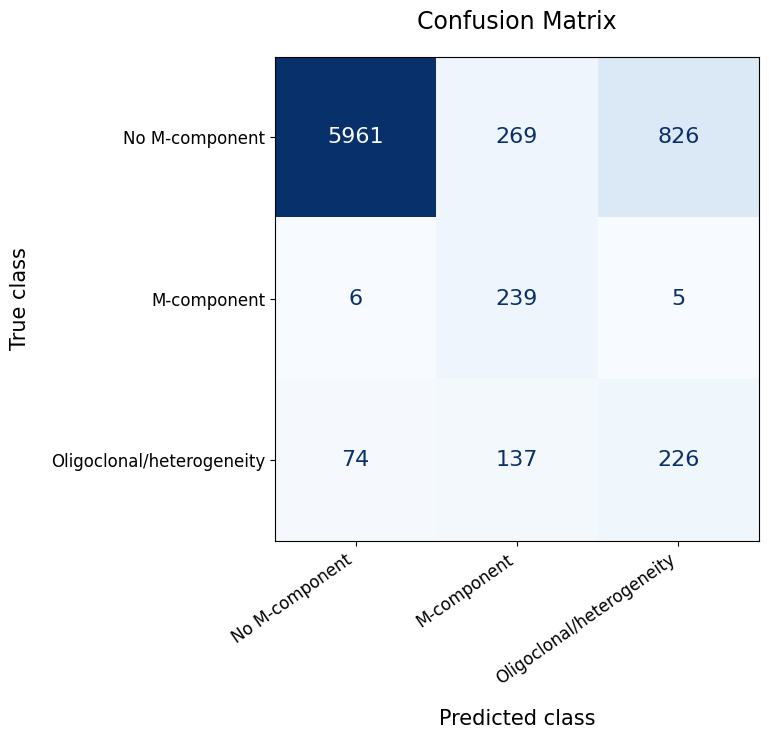

In [37]:
from matplotlib import pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix


cm = confusion_matrix(df['label'], df['final_prediction'])

labels = [
    'No M-component',
    'M-component',
    'Oligoclonal/heterogeneity'
]


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)
fig, ax = plt.subplots(figsize=(7, 7))

disp.plot(
    ax=ax,
    
    colorbar=False,
    cmap='Blues',
    values_format='d'
)

for text in ax.texts:
    text.set_fontsize(16)

ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=12)
ax.set_yticklabels(labels, fontsize=12)

ax.set_xlabel('Predicted class', fontsize=15, labelpad=15)
ax.set_ylabel('True class', fontsize=15, labelpad=15)

ax.set_title('Confusion Matrix', fontsize=17, pad=20)

fig.tight_layout()

# efter tight_layout:
fig.subplots_adjust(
    left=0.18,
    bottom=0.22
)

plt.show()

In [38]:
from matplotlib import pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

df['type'] = 'normal'



mat = np.zeros((3,3))
total_missclassified = sum(df['label'] != df['final_prediction'])
for i in range(3):
    for j in range(3):
        mat[i,j] = sum((df['label'] == i) & (df['final_prediction'] == j))
        #ids |= set(df.loc[(df['label'] == i) & (df['final_prediction'] == j),'row_id' ].sample(int(np.ceil(mat[i,j]))))

ids = set(df.loc[(df['label'] == 1) & (df['final_prediction'] == 0),'row_id' ]) 
ids |= set(df.loc[(df['label'] == 1) & (df['final_prediction'] == 2),'row_id' ])


ids |= set(df.loc[(df['label'] == 0) & (df['final_prediction'] == 1),'row_id' ].sample(22))
ids |= set(df.loc[(df['label'] == 0) & (df['final_prediction'] == 2),'row_id' ].sample(22))
ids |= set(df.loc[(df['label'] == 2) & (df['final_prediction'] == 0),'row_id' ].sample(22))
ids |= set(df.loc[(df['label'] == 2) & (df['final_prediction'] == 1),'row_id' ].sample(22))
ids |= set(df.loc[(df['label'] != df['final_prediction']) & (~df['row_id'].isin(ids)),'row_id' ].sample(1))
df.loc[df['row_id'].isin(ids),'type'] = 'difficult'


ids |= set(df.loc[(df['label'] == 0) & (~df['row_id'].isin(ids)), 'row_id'].sample(50,random_state=42)) 
ids |= set(df.loc[(df['label'] == 1) & (~df['row_id'].isin(ids)), 'row_id'].sample(50,random_state=43))


print(df[df['type'] == 'difficult'].shape[0])

print(len(ids))
print(ids)
df = df[df['row_id'].isin(ids)]
print(len(df))
df.to_csv('classify-samples.csv')

100
200
{184835, 181252, 139781, 100876, 97295, 95762, 144915, 82965, 49688, 89115, 90144, 182307, 177188, 156197, 90661, 155687, 70185, 15916, 119852, 2606, 47152, 150066, 148018, 2614, 82497, 98369, 79427, 108616, 163915, 173132, 109131, 57419, 146006, 94294, 106072, 162390, 119383, 106076, 2659, 146532, 110183, 2669, 115, 152180, 154231, 67705, 103037, 129663, 110209, 35462, 140935, 16523, 74893, 43662, 178318, 58004, 43158, 84635, 103068, 6299, 38044, 96926, 91296, 51366, 73383, 150186, 106155, 166060, 167088, 59569, 158899, 153267, 50872, 42169, 114362, 159936, 141506, 9923, 102084, 82118, 157895, 28364, 128205, 122572, 156880, 95442, 103128, 163035, 91355, 143071, 24811, 111852, 66802, 62711, 143618, 116995, 147718, 95496, 120584, 141578, 183563, 119052, 43787, 70416, 109845, 76572, 3357, 159007, 38181, 56104, 49451, 27948, 140080, 177970, 49972, 6456, 51513, 46396, 99138, 122694, 127302, 167754, 34635, 148300, 26958, 160080, 144208, 166229, 33110, 57182, 162659, 139107, 84327, 1

In [32]:



df = df[['row_id','type','value','albumin','antitrypsin','orosomukoid','haptoglobin','crp','igg','iga','igm']]
con = duckdb.connect('../application/application.db')
con.execute('DROP TABLE IF EXISTS difficult_cases')
con.execute('CREATE TABLE difficult_cases AS SELECT * FROM df')

con.close()


In [ ]:
df = predict(df)